# Chapter 2 - Training Machine Learning Algorithms for Classification

## Core question

How does a classifier change its weights after seeing examples, and what evidence tells us whether those changes achieved the intended objective?

Chapter 1 represented examples as rows of a feature matrix and distinguished learning from evaluation. Here we build two linear classifiers rather than calling a ready-made classifier. The **Perceptron** changes parameters when its predicted class is wrong. **Adaline**, short for adaptive linear neuron, adjusts a continuous output by minimizing mean squared error. Their prediction boundaries can both be straight lines even though their learning rules differ.

We follow the same two Iris measurements from inspecting observations to tracing updates, drawing decision boundaries, deriving gradients, and comparing optimization procedures. All fitted-model results in this chapter are **training-mechanics demonstrations**, not estimates of accuracy on unseen flowers. Chapter 1 has already inspected Iris; we do not rename these observations an untouched test set.

### What you should be able to do

- Calculate a linear net input, apply its stated threshold, and update weights and bias from one example.
- Explain linear separability and distinguish online mistakes from errors made by the final model.
- Derive every component of the Adaline MSE gradient, including its sign, factor 2, and averaging factor.
- Implement full-batch and stochastic gradient descent using visible NumPy calculations.
- Explain how standardization changes numerical optimization without creating new class information.
- Interpret a learning curve using the model state, metric, and computational budget that produced it.

### Reading route and prerequisites

You need Chapter 1's features, targets, dot products, and training/evaluation distinction, plus Python loops and array indexing. The chain rule is developed with intermediate steps rather than assumed as a memorized update formula. The later curvature derivation supplies additional mathematical depth; you can first read its concrete conclusion and return to the matrix argument.

The main sequence is: **data and linear scores → Perceptron updates and limits → Adaline loss and gradients → learning rates and scaling → stochastic and mini-batch updates → interpretation and discussion**. There are no prescribed weekly stopping points. Plotting and table-formatting instructions support the displays; study the calculations rather than memorizing Matplotlib syntax.

The conceptual source is Chapter 2, printed pp.19-51, of *Machine Learning with PyTorch and Scikit-Learn* by Sebastian Raschka, Yuxi (Hayden) Liu, and Vahid Mirjalili. Explanations, worked examples, and graphics here are course-written. Additional mathematical explanations are identified where they extend the textbook's presentation.

## Setup

Run the notebook from top to bottom in a fresh Python kernel. No GPU, login, or data download is required. The environment needs `numpy`, `pandas`, `matplotlib`, `scikit-learn`, and a Jupyter kernel. If a library is missing, install these packages in the same Python environment as the notebook kernel, then restart the kernel. Scikit-learn supplies the small bundled dataset; the learning rules below are implemented with Python and NumPy.

The next cell records the versions actually used and defines display helpers. A fixed seed makes a declared experiment repeatable within the recorded setup; it does not make its conclusion true for every sample or software version.

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from IPython.display import display

SEED = 1
BLUE, ORANGE, GREEN = "#17324D", "#B85C00", "#28745A"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2})
np.set_printoptions(precision=6, suppress=True)
_table_number = 0

def table(frame, caption, formats=None):
    global _table_number
    _table_number += 1
    styled = (frame.style.hide(axis="index").set_uuid(f"ch02_{_table_number}")
              .set_caption(caption).set_table_styles([
                  {"selector": "caption", "props": "text-align:left;font-weight:bold;caption-side:top;"},
                  {"selector": "th", "props": "background:#EAF1F4;text-align:left;"},
                  {"selector": "td", "props": "text-align:left;padding:6px;"}]))
    display(styled.format(formats or {}, precision=4))

def flowers(ax, data, labels, standardized=False):
    for label, name, marker, color in [(0, "Setosa (0)", "o", BLUE),
                                        (1, "Versicolor (1)", "^", ORANGE)]:
        rows = labels == label
        ax.scatter(data[rows, 0], data[rows, 1], marker=marker, color=color,
                   edgecolors="white", linewidths=0.5, s=42, label=name)
    if standardized:
        ax.set(xlabel="Standardized sepal length\n(dimensionless)",
               ylabel="Standardized petal length\n(dimensionless)")
    else:
        ax.set(xlabel="Sepal length (cm)", ylabel="Petal length (cm)")
    ax.legend(fontsize=9)

def boundary(ax, weights, bias, threshold, x_range, label="Decision boundary"):
    # Draw the analytic line, including the vertical-line case.
    if weights[1] != 0:
        xx = np.array(x_range)
        ax.plot(xx, (threshold - bias - weights[0] * xx) / weights[1],
                "k--", linewidth=2, label=label)
    elif weights[0] != 0:
        ax.axvline((threshold - bias) / weights[0], color="black", linestyle="--", label=label)

versions = {"Python": platform.python_version(), "NumPy": np.__version__,
            "pandas": pd.__version__, "Matplotlib": matplotlib.__version__,
            "scikit-learn": sklearn.__version__}
table(pd.DataFrame(versions.items(), columns=["Component", "Executed version"]),
      "Environment for the preserved outputs; random seed = 1 unless stated otherwise")

Component,Executed version
Python,3.12.9
NumPy,2.2.6
pandas,2.2.3
Matplotlib,3.10.8
scikit-learn,1.8.0


## 1. Which observations and measurements will the classifier use?

An observation is one measured Iris flower, not a person, a region, or a future observation. We select **setosa and versicolor** and use **sepal length and petal length**, both measured in centimeters. Class 0 means setosa and class 1 means versicolor. The integer labels encode categories; a label of 1 does not mean that a species has a larger biological value.

We retain Chapter 1's `load_iris(as_frame=True)` data source. The textbook's bundled UCI file differs from this version at three entries across the full four-feature dataset. One difference affects our selected petal-length column: zero-based row 37 is 1.4 cm here and 1.5 cm in the book's bundled file. Recompute results rather than assuming identical data because both files are called Iris.

**Before execution:** predict the shape of `X` and the number of targets in each class. In the scatter plot, predict whether petal length alone might separate these particular observed classes. This is a prediction about the displayed sample, not the population of all flowers.

In [2]:
iris = load_iris(as_frame=True)
feature_names = ["sepal length (cm)", "petal length (cm)"]
selected = iris.target.isin([0, 1])
frame = iris.data.loc[selected, feature_names].copy()
X = frame.to_numpy(dtype=float)
y = iris.target.loc[selected].to_numpy(dtype=int)
n, m = X.shape
preview = frame.loc[[0, 37, 49, 50, 99]].copy()
preview.insert(0, "Iris row (zero-based)", preview.index)
preview["Species / target"] = [f"{iris.target_names[v]} / {v}" for v in y[preview.index]]
table(preview, "Selected scikit-learn Iris observations; two unmodified measurements in cm",
      {name: "{:.1f}" for name in feature_names})
table(pd.DataFrame({"Species": ["Setosa", "Versicolor"], "Target": [0, 1],
                    "Rows": [(y == 0).sum(), (y == 1).sum()],
                    "Min petal (cm)": [X[y == k, 1].min() for k in [0, 1]],
                    "Max petal (cm)": [X[y == k, 1].max() for k in [0, 1]]}),
      f"Training-mechanics sample: X has shape {X.shape}; no held-out evaluation",
      {"Min petal (cm)": "{:.1f}", "Max petal (cm)": "{:.1f}"})

Iris row (zero-based),sepal length (cm),petal length (cm),Species / target
0,5.1,1.4,setosa / 0
37,4.9,1.4,setosa / 0
49,5.0,1.4,setosa / 0
50,7.0,4.7,versicolor / 1
99,5.7,4.1,versicolor / 1


Species,Target,Rows,Min petal (cm),Max petal (cm)
Setosa,0,50,1.0,1.9
Versicolor,1,50,3.0,5.1


`X` has 100 rows and 2 columns, and each class contributes 50 targets. The inspected petal lengths span 1.0-1.9 cm for setosa and 3.0-5.1 cm for versicolor. That gap permits a separating threshold for this sample. Selecting visibly separable classes makes learning easy to inspect; it does not establish that arbitrary species pairs or new measurements will be separated equally well.

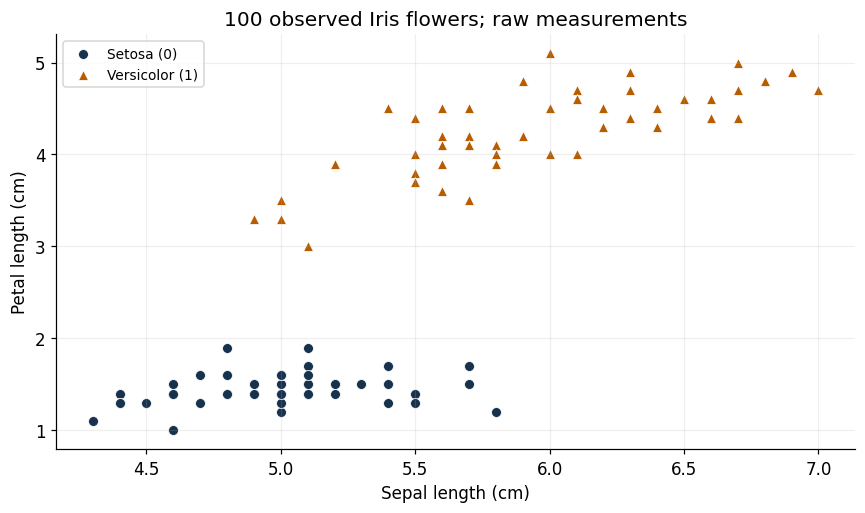

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.8))
flowers(ax, X, y)
ax.set_title("100 observed Iris flowers; raw measurements")
fig.tight_layout()
plt.show()

The circles and triangles occupy separate vertical ranges, while their sepal-length ranges overlap. Therefore a two-feature model is not needed merely to obtain zero error on this selected sample. We still use two features to make the roles of weights, geometry, and feature scaling visible.

**Check your reasoning:** why would adding virginica change the learning problem even if the feature columns and their units stayed the same?

## 2. How do measurements become a predicted class?

The textbook introduces artificial neurons through an early input-integration-output analogy. A weighted sum followed by a rule is a mathematical simplification, not a simulation of the biological mechanisms of a neuron. Our classifier receives feature values, combines them, and emits a class prediction; the target is needed for learning, not for making that prediction.

For observation $i$, the **net input** is a weighted sum. With $m$ features and threshold $\theta$, predicting class 1 when $\sum_{j=1}^{m}w_jx_{ij}\ge\theta$ is equivalent to introducing the **bias** $b=-\theta$:

$$
z_i=\sum_{j=1}^{m}w_jx_{ij}+b,\qquad
\hat y_i=\begin{cases}1,&z_i\ge0,\\0,&z_i<0.\end{cases}
$$

Here $x_{ij}$ is feature $j$ of observation $i$, $w_j$ is its coefficient, $b$ shifts the threshold, and $\hat y_i$ is the predicted category. We treat the net input and bias as dimensionless. A weight multiplying a measurement in cm has reciprocal-cm units so the products can be added. The learning rule operates on numerical coordinates; rescaling a measurement affects the numerical updates, as we investigate later.

The equality convention matters: this chapter predicts **1 at $z=0$**, matching the book's implemented Perceptron. Chapter 1's illustrative rule used a strict positive comparison. Neither tie rule is universal; it must be specified.

For all examples at once, let $X\in\mathbb R^{n\times m}$, $\mathbf w\in\mathbb R^{m\times1}$, and $\mathbf 1\in\mathbb R^{n\times1}$:

$$
\mathbf z=X\mathbf w+b\mathbf1.
$$

Chapter 1 wrote an example as a row $\mathbf x^{(i)}\in\mathbb R^{1\times m}$, so $z_i=\mathbf x^{(i)}\mathbf w+b$. The textbook's column-example form $\mathbf w^\top\mathbf x^{(i)}_{\mathrm{col}}+b$ gives the same scalar. In NumPy, a shape `(m,)` array is one-dimensional; `.T` does not turn it into a column matrix. `X @ w` directly produces the shape `(n,)` vector we need.

**Before execution:** use the artificial rule $z=-x_1+x_2-1$ to predict the class of $(1,2)$. Decide which feature values lie on the boundary and whether the step function ever outputs a negative class value.

x1 (dimensionless),x2 (dimensionless),Net input z,Prediction (z >= 0)
1.0000,1.0000,-1.0000,0
1.0000,2.0000,0.0000,1
1.0000,3.0000,1.0000,1


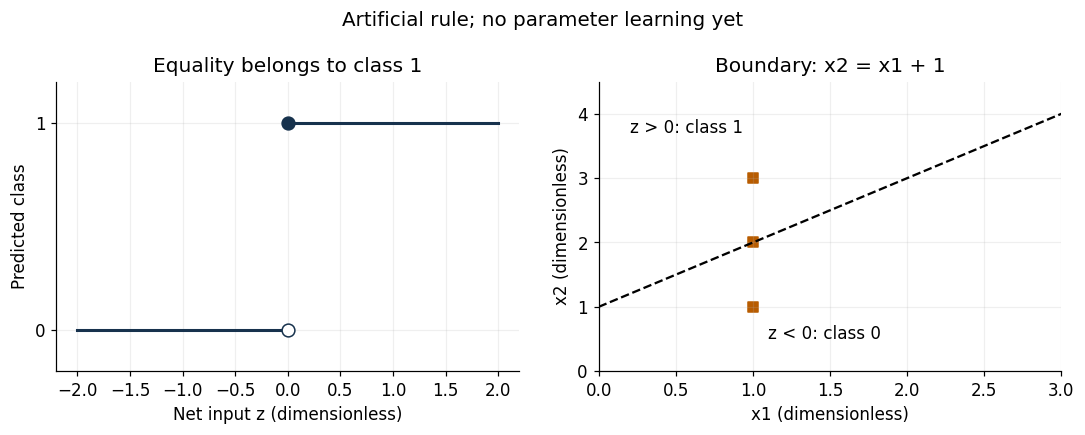

In [4]:
# Artificial coordinate example, not measured Iris data.
example_X = np.array([[1., 1.], [1., 2.], [1., 3.]])
example_w = np.array([-1., 1.])
example_b = -1.
example_z = example_X @ example_w + example_b
table(pd.DataFrame({"x1 (dimensionless)": example_X[:, 0],
                    "x2 (dimensionless)": example_X[:, 1], "Net input z": example_z,
                    "Prediction (z >= 0)": (example_z >= 0).astype(int)}),
      "Artificial threshold calculation: z = -x1 + x2 - 1")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([-2, 0], [0, 0], color=BLUE, linewidth=2)
axes[0].plot([0, 2], [1, 1], color=BLUE, linewidth=2)
axes[0].scatter([0], [0], facecolors="white", edgecolors=BLUE, s=70, zorder=4)
axes[0].scatter([0], [1], color=BLUE, s=70, zorder=4)
axes[0].set(xlabel="Net input z (dimensionless)", ylabel="Predicted class",
            title="Equality belongs to class 1", yticks=[0, 1], ylim=(-.2, 1.2))
xx = np.linspace(0, 3, 100)
axes[1].plot(xx, xx + 1, "k--")
axes[1].text(.2, 3.7, "z > 0: class 1")
axes[1].text(1.1, .5, "z < 0: class 0")
axes[1].scatter(example_X[:, 0], example_X[:, 1], color=ORANGE, marker="s")
axes[1].set(xlabel="x1 (dimensionless)", ylabel="x2 (dimensionless)",
            title="Boundary: x2 = x1 + 1", xlim=(0, 3), ylim=(0, 4.5))
fig.suptitle("Artificial rule; no parameter learning yet", fontsize=13)
fig.tight_layout()
plt.show()

The table gives net inputs $-1,0,1$ and predictions $0,1,1$. In particular, $(1,2)$ lies exactly on the dashed line and receives class 1. The function outputs 0 or 1, never a negative value; the **net input**, not the predicted category, is negative below the boundary.

For two features with $w_2\ne0$, solving the zero-score equation gives a course-added geometric explanation:

$$
w_1x_1+w_2x_2+b=0
\quad\Longrightarrow\quad
x_2=-\frac{w_1}{w_2}x_1-\frac{b}{w_2}.
$$

The ratios determine slope and intercept. If $w_2=0$ but $w_1\ne0$, the boundary is vertical: $x_1=-b/w_1$. If both weights are zero, the prediction is constant; there is no unique separating line. Plotting a coarse grid can produce stair-shaped edges, but that does not make the underlying linear rule nonlinear.

## 3. What does one Perceptron update change?

The Perceptron uses the difference between the true class $y_i$ and the predicted class $\hat y_i$. First calculate the prediction with the **old** parameters. Then calculate all parameter changes from that same prediction:

$$
\Delta w_j=\eta(y_i-\hat y_i)x_{ij},\qquad
\Delta b=\eta(y_i-\hat y_i),\qquad \eta>0.
$$

The learning rate $\eta$ sets the numerical step size. Apply $w_j\leftarrow w_j+\Delta w_j$ and $b\leftarrow b+\Delta b$. A correct prediction gives zero changes. A mistaken class-0 prediction for a class-1 target gives a positive label error; the reverse mistake gives a negative error. Compute once, then update: recalculating the prediction between individual weight changes would implement a different procedure.

The following original diagram separates using a model from changing it. **Before execution:** predict where the true target must enter the flow and whether it is available or required on the upper prediction path.

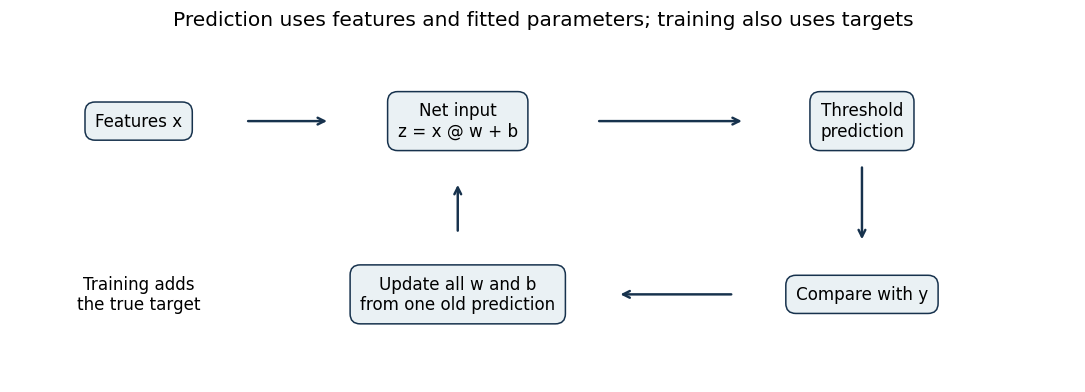

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.7))
ax.set(xlim=(0, 10), ylim=(0, 4))
ax.axis("off")
boxes = [(1.2, 3, "Features x"), (4.2, 3, "Net input\nz = x @ w + b"),
         (8, 3, "Threshold\nprediction"), (8, 1, "Compare with y"),
         (4.2, 1, "Update all w and b\nfrom one old prediction")]
for x0, y0, text in boxes:
    ax.text(x0, y0, text, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=.6", facecolor="#EAF1F4", edgecolor=BLUE))
for start, end in [((2.2, 3), (3, 3)), ((5.5, 3), (6.9, 3)),
                   ((8, 2.5), (8, 1.6)), ((6.8, 1), (5.7, 1)), ((4.2, 1.7), (4.2, 2.3))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.6))
ax.text(1.2, 1, "Training adds\nthe true target", ha="center", va="center")
ax.set_title("Prediction uses features and fitted parameters; training also uses targets")
fig.tight_layout()
plt.show()

The upper path has three steps and no target input. The lower path uses $y$ to change the parameters for subsequent predictions. A model can therefore predict an unknown label, but the supervised update shown here cannot be calculated without a training target.

### Why does the update move the same example's score in the intended direction?

This course-added derivation substitutes the update into the score of the **same unchanged example**:

$$
\begin{aligned}
z_i^{\mathrm{new}}-z_i^{\mathrm{old}}
&=\sum_jx_{ij}(w_j^{\mathrm{new}}-w_j^{\mathrm{old}})
 +(b^{\mathrm{new}}-b^{\mathrm{old}})\\
&=\sum_jx_{ij}\eta(y_i-\hat y_i)x_{ij}+\eta(y_i-\hat y_i)\\
&=\eta(y_i-\hat y_i)\left(\sum_jx_{ij}^2+1\right).
\end{aligned}
$$

For a nonzero label error, the bracket is positive, so the change has the sign of the error. This explains the direction, not a guarantee that one step crosses zero. Nor does it guarantee improvement for another example $\mathbf x^{(k)}$: its score changes by $\eta(y_i-\hat y_i)(\sum_jx_{kj}x_{ij}+1)$, which can have a different sign. These are statements about the fixed numerical coordinate system used by the learning rule.

**Before execution:** for the artificial scalar input $x=1.5$, target 1, old prediction 0, and $\eta=1$, calculate the weight change, bias change, and score change separately. Then predict how a negative feature changes the weight update without reversing the intended score correction.

In [6]:
# Artificial one-feature examples. Each row starts a separate experiment.
rows = []
for target, old_prediction, xi in [(0, 0, 1.5), (0, 1, 1.5),
                                    (1, 0, 1.5), (1, 1, 1.5), (1, 0, -1.5)]:
    old_w = 0.
    old_b = 1. if old_prediction == 1 else -1.
    predicted = int(old_w * xi + old_b >= 0)
    dw = (target - predicted) * xi  # eta = 1
    db = float(target - predicted)
    dz = (old_w + dw) * xi + old_b + db - (old_w * xi + old_b)
    rows.append([target, predicted, xi, dw, db, dz])
table(pd.DataFrame(rows, columns=["Target", "Old prediction", "x", "Delta w", "Delta b", "Delta z"]),
      "Artificial one-feature updates; eta = 1; coordinates and scores dimensionless")

Target,Old prediction,x,Delta w,Delta b,Delta z
0,0,1.5000,0.0000,0.0000,0.0000
0,1,1.5000,-1.5000,-1.0000,-3.2500
1,0,1.5000,1.5000,1.0000,3.2500
1,1,1.5000,0.0000,0.0000,0.0000
1,0,-1.5000,-1.5000,1.0000,3.2500


The target-1/prediction-0 row with $x=1.5$ has $\Delta w=1.5$, $\Delta b=1$, and $\Delta z=3.25$. Adding $1.5+1$ does **not** calculate the score change: the changed weight must multiply $x$ again. When $x=-1.5$, the weight change is $-1.5$ but the score still increases by $3.25$. Both correct-prediction rows have zero changes.

**Check your reasoning:** if the old score were $-10$ instead of $-1$ for the positive target, would the same $3.25$ increase fix the prediction in one step? Explain using the threshold rather than the direction alone.

## 4. How do repeated updates become a fitted classifier?

An **epoch** is one pass through the selected training rows. We keep the textbook's class-grouped order, small random initial weights with seed 1, initial bias zero, and learning rate 0.1. Order is part of this experiment; shuffling may produce another sequence of mistakes and another separator.

The readable loop below stores two different counts after each pass. `updates` counts mistakes at the instant each row is visited, while the weights are changing. `end_errors` evaluates all rows once more with the final parameters held fixed. A count from one procedure cannot be silently labeled as the other.

The small input-checking function rejects empty, nonfinite, or incorrectly shaped arrays. It does not fill missing values or change their meaning. One example is represented as a two-dimensional array with one row, keeping the feature dimension unambiguous. These are teaching functions, not a complete scikit-learn estimator interface.

**Before execution:** predict whether the two error counts must match. In particular, could the last update of an epoch leave no final errors even though that epoch contained mistakes?

In [7]:
def checked_xy(data, targets):
    data = np.asarray(data, dtype=float)
    targets = np.asarray(targets)
    if data.ndim != 2 or data.shape[0] == 0 or data.shape[1] == 0:
        raise ValueError("X must be a nonempty 2D array: rows are examples.")
    if targets.ndim != 1 or len(targets) != len(data):
        raise ValueError("y must be a 1D array with one target per row.")
    if not np.isfinite(data).all() or not np.isin(targets, [0, 1]).all():
        raise ValueError("Use finite features and binary targets 0 or 1.")
    return data, targets.astype(float)

def perceptron(data, targets, eta=0.1, epochs=10, zero_start=False):
    data, targets = checked_xy(data, targets)
    if not np.isfinite(eta) or eta <= 0 or not isinstance(epochs, int) or epochs < 1:
        raise ValueError("Use a positive finite eta and a positive integer epoch count.")
    rng = np.random.RandomState(SEED)
    w = np.zeros(data.shape[1]) if zero_start else rng.normal(0., .01, data.shape[1])
    b = 0.
    history = []
    for epoch in range(1, epochs + 1):
        updates = 0
        for xi, target in zip(data, targets):
            prediction = int(xi @ w + b >= 0)
            change = eta * (target - prediction)
            w += change * xi
            b += change
            updates += int(change != 0)
        end_predictions = (data @ w + b >= 0).astype(int)
        history.append([epoch, updates, int(np.count_nonzero(end_predictions != targets))])
    return w, b, pd.DataFrame(history, columns=["Epoch", "Online updates", "End errors"])

pw, pb, ph = perceptron(X, y)
table(ph, "100 Iris training rows, fixed class-grouped order; eta = 0.1, seed = 1")
table(pd.DataFrame({"Parameter": ["Sepal-length weight", "Petal-length weight", "Bias"],
                    "Value": [*pw, pb], "Unit": ["per cm", "per cm", "dimensionless"]}),
      "Final Perceptron after ten passes over the same 100 Iris rows", {"Value": "{:.6f}"})

Epoch,Online updates,End errors
1,2,50
2,2,50
3,3,50
4,2,50
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0
10,0,0


Parameter,Value,Unit
Sepal-length weight,-0.353757,per cm
Petal-length weight,0.913882,per cm
Bias,-0.200000,dimensionless


The online-update counts are **2, 2, 3, 2, 1, 0, 0, 0, 0, 0**, while the frozen end-of-epoch errors are **50, 50, 50, 50, 0, 0, 0, 0, 0, 0**. Epoch 5 contains an update but finishes with zero errors. Epoch 6 then visits every row without changing the parameters. These are distinct observations: a zero-update complete pass verifies stability on this training sample, while the earlier end-of-epoch evaluation already establishes its final classifications.

The fitted parameters are $w_1=\text{-0.353757}$ per cm, $w_2=\text{0.913882}$ per cm, and $b=\text{-0.200}$. Substituting these parameters into the boundary equation gives the dashed line below. **Before execution:** predict which side of that line contains the 50 versicolor triangles, and where the update and end-error curves will disagree.

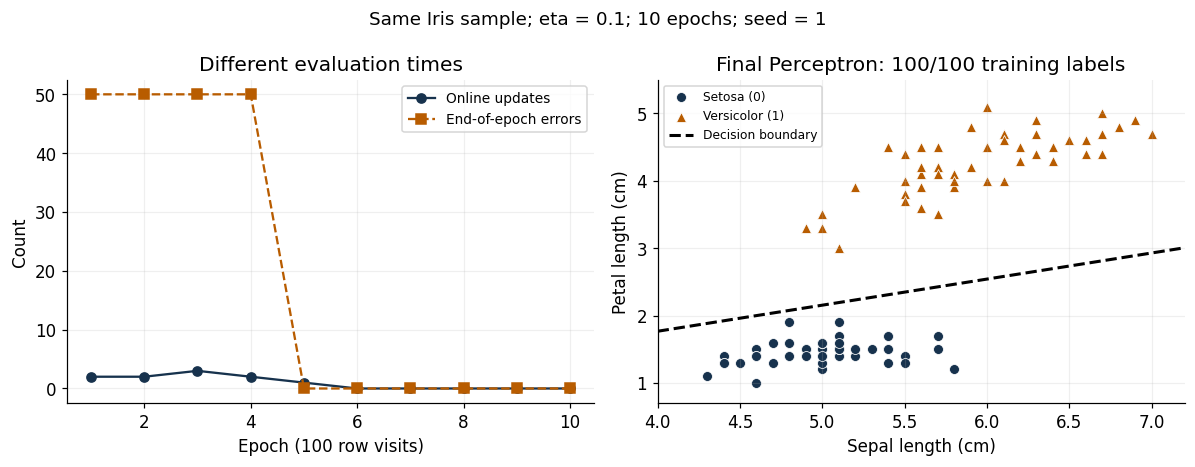

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(ph["Epoch"], ph["Online updates"], "o-", color=BLUE, label="Online updates")
axes[0].plot(ph["Epoch"], ph["End errors"], "s--", color=ORANGE, label="End-of-epoch errors")
axes[0].set(xlabel="Epoch (100 row visits)", ylabel="Count", title="Different evaluation times")
axes[0].legend(fontsize=9)
flowers(axes[1], X, y)
boundary(axes[1], pw, pb, 0, [4, 7.2])
axes[1].set(xlim=(4, 7.2), ylim=(.7, 5.5), title="Final Perceptron: 100/100 training labels")
axes[1].legend(fontsize=8)
fig.suptitle("Same Iris sample; eta = 0.1; 10 epochs; seed = 1", fontsize=12)
fig.tight_layout()
plt.show()

The first four epochs illustrate why a small online-update count need not mean a small frozen-model error count: later rows can undo earlier classifications. The right panel separates all 100 displayed training flowers, with versicolor above the line. Many lines could separate these points. This run does not identify a unique best separator, a maximum-margin solution, or the most accurate rule for future flowers.

### What would the textbook's object-oriented interface add?

In the official class, `fit(X, y)` stores fitted weights and bias on an object; `net_input(X)` calculates its scores; `predict(X)` thresholds those scores. Our function returns the weights, bias, and history explicitly so their flow remains visible. The computation, not the presence of a class, is the learning algorithm. Re-running `perceptron` starts training again; it does not continue from the previous weights.

## 5. When can the Perceptron stop making mistakes?

The textbook's convergence statement requires **linearly separable training data**: a single linear boundary can correctly classify the finite sample. Under that condition, a positive fixed learning rate and repeated passes give the usual Perceptron convergence result. A fixed epoch budget alone is not a proof of convergence. A classifier may stop because its budget ran out while still making mistakes.

The following artificial points separate geometry from Iris biology. The XOR targets assign class 1 to $(0,1)$ and $(1,0)$, and class 0 to $(0,0)$ and $(1,1)$. With our tie rule, correct class-0 predictions require strict negative scores. Correct classification would require:

$$
b<0,\qquad w_2+b\ge0,\qquad w_1+b\ge0,\qquad w_1+w_2+b<0.
$$

The two middle inequalities imply $w_1+w_2+2b\ge0$, hence $w_1+w_2+b\ge-b>0$. This contradicts the last inequality. This course-added argument proves that these four points cannot be classified by this linear rule. A finite unsuccessful run by itself would not prove that fact.

**Before execution:** predict whether increasing the XOR run from 10 to 20 epochs can remove the geometric contradiction. Compare it with the artificial sample whose labels depend only on its second coordinate.

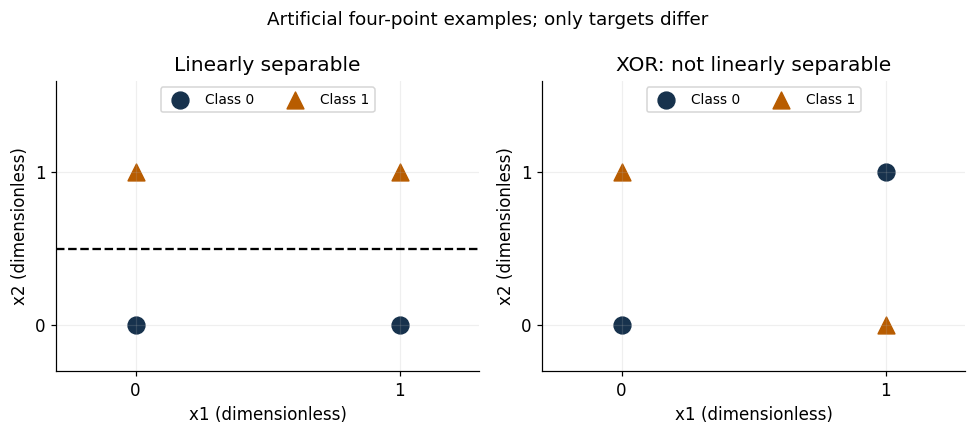

Epoch,Online updates,End errors
18,4,2
19,4,2
20,4,2


In [9]:
# Artificial binary-coordinate examples, not Iris.
xor_X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
xor_y = np.array([0, 1, 1, 0])
sep_y = np.array([0, 1, 0, 1])
xw, xb, xh = perceptron(xor_X, xor_y, eta=.1, epochs=20, zero_start=True)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, labels, title in zip(axes, [sep_y, xor_y], ["Linearly separable", "XOR: not linearly separable"]):
    for label, marker, color in [(0, "o", BLUE), (1, "^", ORANGE)]:
        ax.scatter(xor_X[labels == label, 0], xor_X[labels == label, 1],
                   marker=marker, s=120, color=color, label=f"Class {label}")
    ax.set(xlabel="x1 (dimensionless)", ylabel="x2 (dimensionless)",
           title=title, xlim=(-.3, 1.3), ylim=(-.3, 1.6), xticks=[0, 1], yticks=[0, 1])
    ax.legend(fontsize=9, loc="upper center", ncol=2)
axes[0].axhline(.5, color="black", linestyle="--")
fig.suptitle("Artificial four-point examples; only targets differ", fontsize=12)
fig.tight_layout()
plt.show()
table(xh.tail(3), "Artificial XOR: zero initialization, eta = 0.1, fixed order, four visits per epoch")

The separable panel admits the horizontal line $x_2=0.5$. The XOR run still makes **4** updates in epoch 20 and ends with **2** wrong labels. Those counts describe this order and initialization; the contradiction above establishes why no change of Perceptron weights can classify all four XOR points.

**Check your reasoning:** should you first increase epochs or reconsider the representation when the target pattern is exactly XOR in these two input coordinates? Distinguish what more computation can change from what a straight boundary can represent.

### Does the learning rate always change a Perceptron's predictions?

The textbook notes a special case: with zero weights and zero bias initially, changing a **positive** fixed learning rate scales the parameters but can leave predictions unchanged. Here is the course-expanded reasoning. Compare a run at rate $\eta$ with a run at rate $c\eta$, $c>0$. Suppose before a visit that $\tilde{\mathbf w}=c\mathbf w$ and $\tilde b=cb$. Then $\tilde z=cz$, so signs and equality are preserved and both runs make the same prediction. Their increments also differ by the factor $c$, preserving the relationship after the visit. The initial zero parameters satisfy the relationship, so induction applies at every visit in exact arithmetic with the same row order and tie rule.

The angle formula explains the weight-vector geometry when both vectors are nonzero. Here $\lVert\mathbf w\rVert_2=\sqrt{\sum_jw_j^2}$ is the Euclidean length and $\alpha$ is the angle between the two weight vectors:

$$
\cos\alpha=\frac{\mathbf w^\top\tilde{\mathbf w}}
 {\lVert\mathbf w\rVert_2\lVert\tilde{\mathbf w}\rVert_2}=1,
\qquad \alpha=0.
$$

Scaling the bias too preserves the boundary location. This argument does not apply to unchanged nonzero random initial parameters, negative scaling, different orders, or arbitrary floating-point extremes. **Before execution:** predict the parameter ratio for rates 0.125 and 1.0 and whether the complete update-count sequences will differ.

In [10]:
wa, ba, ha = perceptron(X, y, eta=.125, zero_start=True)
wb, bb, hb = perceptron(X, y, eta=1., zero_start=True)
cosine = np.dot(wa, wb) / (np.linalg.norm(wa) * np.linalg.norm(wb))
angle = np.degrees(np.arccos(np.clip(cosine, -1., 1.)))
table(pd.DataFrame({"Parameter": ["w1 (per cm)", "w2 (per cm)", "b (dimensionless)"],
                    "eta = 0.125": [*wa, ba], "eta = 1": [*wb, bb],
                    "8 x first run": list(8 * np.r_[wa, ba])}),
      "Iris Perceptron, zero start, same order and ten epochs; only positive eta differs")
print("Same update sequence:", ha["Online updates"].equals(hb["Online updates"]))
print("All parameters scaled by 8:", np.allclose(np.r_[wb, bb], 8 * np.r_[wa, ba]))
print("Weight-vector angle (degrees):", round(float(angle), 6))

Parameter,eta = 0.125,eta = 1,8 x first run
w1 (per cm),-0.4250,-3.4000,-3.4000
w2 (per cm),1.1375,9.1000,9.1000
b (dimensionless),-0.2500,-2.0000,-2.0000


Same update sequence: True
All parameters scaled by 8: True
Weight-vector angle (degrees): 0.0


Both Boolean checks return `True`: the complete update sequence agrees and all parameters scale by 8. The displayed weight-vector angle is **0.000000 degrees**. The proof explains the special-case relationship; the output checks this numerical run. Neither says that tuning every Perceptron's learning rate is irrelevant.

### More than two classes

The textbook introduces **one-versus-all**, also called **one-versus-rest**, as a way to train one binary classifier per class. With a consistently defined score for each classifier, predict the class with the largest **signed** score. Taking absolute values would reverse the meaning of a strongly negative score. For example, scores $[-10,2,1]$ select class 1 by the signed maximum, whereas absolute values select class 0 despite its negative score. These scores are not calibrated probabilities, and independently rescaling each binary classifier can alter their cross-class comparison. Chapter 3 develops multiclass interfaces; this chapter's experiments remain binary.

## 6. Why does Adaline learn from a continuous output?

The Perceptron asks whether a class prediction is wrong. Adaline asks how far a **continuous activation** is from the numerical target. Its net input still has the form $z_i=\mathbf x^{(i)}\mathbf w+b$, but during learning its activation is the identity function:

$$
\phi(z_i)=z_i.
$$

Using the book's 0/1 targets, the final Adaline classification rule is:

$$
\hat y_i=\begin{cases}1,&z_i\ge0.5,\\0,&z_i<0.5.\end{cases}
$$

The threshold of 0.5 lies halfway between the target values 0 and 1. It is **not** a statement that $z_i$ is a probability. Unlike the Perceptron, the Adaline weight update does not use the thresholded class prediction. It uses the residual $e_i=y_i-z_i$, which can remain nonzero when the predicted category is already correct.

**Before execution:** for a target of 1, compare activations 0.6 and 1.4. Both exceed 0.5; predict whether their residuals have the same sign, and calculate their squared losses.

In [11]:
# Artificial activation values, not fitted Iris scores.
activation = np.array([.4, .6, 1., 1.4])
target = np.ones(4)
residual = target - activation
table(pd.DataFrame({"Activation z": activation, "Target": target.astype(int),
                    "Adaline class": (activation >= .5).astype(int),
                    "Residual y - z": residual, "Squared loss": residual ** 2}),
      "Artificial target-1 examples; Adaline threshold = 0.5; all quantities dimensionless")
table(pd.DataFrame({"Algorithm": ["Perceptron", "Adaline"],
                    "Value used to learn": ["y - predicted class", "y - continuous z"],
                    "Class-1 threshold": ["z >= 0", "z >= 0.5"],
                    "Correct class, nonzero update?": ["No", "Yes, if residual is nonzero"]}),
      "Same linear net input, different learning signals; binary targets 0/1")

Activation z,Target,Adaline class,Residual y - z,Squared loss
0.4000,1,0,0.6000,0.3600
0.6000,1,1,0.4000,0.1600
1.0000,1,1,0.0000,0.0000
1.4000,1,1,-0.4000,0.1600


Algorithm,Value used to learn,Class-1 threshold,"Correct class, nonzero update?"
Perceptron,y - predicted class,z >= 0,No
Adaline,y - continuous z,z >= 0.5,"Yes, if residual is nonzero"


The 0.6 and 1.4 activations both predict class 1, but their residuals are $+0.4$ and $-0.4$. Both squared losses equal 0.16. Learning should increase the first activation and decrease the second toward 1; thresholded correctness alone cannot express that distinction. Only the activation exactly equal to 1 has zero residual in this table.

**Check your reasoning:** could an Adaline training run reduce MSE while leaving every class prediction unchanged? Use two rows of the table to explain a possible change rather than simply answering yes or no.

## 7. Where does the gradient update come from?

Adaline minimizes **mean squared error (MSE)** over the $n$ training examples:

$$
L(\mathbf w,b)=\frac1n\sum_{i=1}^{n}(y_i-z_i)^2
 =\frac1n\sum_{i=1}^{n}e_i^2.
$$

The targets and activations are dimensionless, so this MSE is dimensionless squared error, not a count of wrongly classified flowers. Every row contributes to the average. Using a sum instead would multiply the gradient by $n$ and change the numerical step at the same learning rate.

### Derivative of one weight

The chain rule differentiates the square and then the expression being squared. To avoid confusing an observation index with a feature index, use $i$ for examples, $j$ for the weight being differentiated, and $k$ inside the feature sum:

$$
e_i=y_i-\left(\sum_{k=1}^{m}w_kx_{ik}+b\right),\qquad
\frac{\partial e_i}{\partial w_j}=-x_{ij}.
$$

The bias appears **once after the sum**, not once per feature. The data and targets are fixed while we differentiate with respect to the parameters. All terms $w_kx_{ik}$ with $k\ne j$ have derivative zero with respect to $w_j$. Therefore:

$$
\begin{aligned}
\frac{\partial L}{\partial w_j}
&=\frac1n\sum_{i=1}^{n}\frac{\partial(e_i^2)}{\partial w_j}\\
&=\frac1n\sum_{i=1}^{n}2e_i\frac{\partial e_i}{\partial w_j}\\
&=-\frac2n\sum_{i=1}^{n}e_ix_{ij}.
\end{aligned}
$$

### Derivative of the bias

For every example, $\partial e_i/\partial b=-1$, not $-m$. Consequently:

$$
\frac{\partial L}{\partial b}
=\frac1n\sum_{i=1}^{n}2e_i(-1)
=-\frac2n\sum_{i=1}^{n}e_i.
$$

The residual vector is not itself the gradient. A weight derivative combines residuals with a feature column; the bias derivative averages the residuals and multiplies by $-2$.

### Move opposite to the gradient

The gradient points toward the locally steepest increase under the ordinary Euclidean parameter coordinates. A sufficiently small step in the opposite direction reduces this smooth loss. Subtracting the negative derivative produces the implemented plus sign:

$$
w_j\leftarrow w_j-\eta\frac{\partial L}{\partial w_j}
=w_j+\frac{2\eta}{n}\sum_i e_ix_{ij},\qquad
b\leftarrow b+2\eta\operatorname{mean}(\mathbf e).
$$

Both changes use residuals from the same old parameters. With $X$ of shape $(n,m)$ and $\mathbf e$ of shape $(n,1)$, $X^\top\mathbf e$ has shape $(m,1)$:

$$
\mathbf w\leftarrow\mathbf w+\frac{2\eta}{n}X^\top\mathbf e.
$$

NumPy uses one-dimensional `(m,)` and `(n,)` arrays for weights and residuals here. `X.T @ residual` still computes the required sum for each feature; elementwise multiplication by itself does not perform that summation.

### A numerical derivative check

This course-added example compares the analytic gradient with **central finite differences**. For parameter coordinate $q$ and unit vector $\mathbf u_q$, approximate the derivative by:

$$
\frac{\partial L}{\partial\beta_q}
\approx\frac{L(\boldsymbol\beta+h\mathbf u_q)-L(\boldsymbol\beta-h\mathbf u_q)}{2h},
\qquad \boldsymbol\beta=(w_1,w_2,b)^\top.
$$

Here $h=10^{-6}$ is a small numerical displacement in one parameter coordinate; all other coordinates and all data stay fixed. Taking $h$ arbitrarily close to zero is not automatically more accurate because subtraction and floating-point rounding then matter.

**Before execution:** for the displayed artificial three-row dataset and initial parameters, calculate the three residuals. Predict the sign of the bias derivative from their mean. Then compare the feature-loop, matrix, and finite-difference gradients.

In [12]:
# Artificial, dimensionless three-row derivative example; not Iris.
toy_X = np.array([[1., 2.], [-1., 1.], [2., -1.]])
toy_y = np.array([1., 0., 1.])
toy_beta = np.array([.2, -.1, .3])  # w1, w2, bias

def mse(data, targets, w, b):
    return float(np.mean((targets - (data @ w + b)) ** 2))

toy_z = toy_X @ toy_beta[:2] + toy_beta[2]
toy_e = toy_y - toy_z
gradient_loop = np.array([-2 * np.mean(toy_e * toy_X[:, j]) for j in range(2)])
gradient = np.r_[-2 * toy_X.T @ toy_e / len(toy_y), -2 * toy_e.mean()]
numerical = np.zeros(3)
h = 1e-6
for q in range(3):
    plus, minus = toy_beta.copy(), toy_beta.copy()
    plus[q] += h
    minus[q] -= h
    numerical[q] = (mse(toy_X, toy_y, plus[:2], plus[2]) -
                    mse(toy_X, toy_y, minus[:2], minus[2])) / (2 * h)
table(pd.DataFrame({"x1": toy_X[:, 0], "x2": toy_X[:, 1], "y": toy_y,
                    "z": toy_z, "Residual y-z": toy_e}),
      "Artificial derivative example; w = [0.2, -0.1], b = 0.3; dimensionless values rounded for display")
table(pd.DataFrame({"Parameter": ["w1", "w2", "b"], "Analytic derivative": gradient,
                    "Finite difference": numerical, "Absolute difference": abs(gradient - numerical)}),
      "Same artificial loss and parameters; one coordinate perturbed at a time; h = 1e-6",
      {"Analytic derivative": "{:.6f}", "Finite difference": "{:.6f}", "Absolute difference": "{:.2e}"})
assert np.allclose(gradient_loop, gradient[:2])

x1,x2,y,z,Residual y-z
1.0000,2.0000,1.0000,0.3000,0.7000
-1.0000,1.0000,0.0000,-0.0000,0.0000
2.0000,-1.0000,1.0000,0.8000,0.2000


Parameter,Analytic derivative,Finite difference,Absolute difference
w1,-0.733333,-0.733333,2.58e-12
w2,-0.800000,-0.800000,2.30e-11
b,-0.600000,-0.600000,2.44e-11


The residuals are 0.7, 0, and 0.2, so the bias derivative is $-2(0.9/3)=-0.6$. The table gives the full analytic gradient **[-0.733333, -0.800000, -0.600000]**. Its largest absolute difference from central finite differences is **2.44e-11**, and the loop agrees with the matrix calculation. This check supports the implementation at these inputs; it is not a replacement for the chain-rule derivation.

**Check your reasoning:** where would a mistakenly repeated bias inside the two-feature sum first change this derivation? Calculate the resulting derivative of the score with respect to the bias before discussing the loss.

## 8. Why can a large learning rate increase the loss?

To see the direction and size of a step without a high-dimensional plot, temporarily restrict Adaline to a **bias-only artificial example** with two targets $[0,1]$. All feature weights are fixed to zero, so every activation equals $b$. This is a course-added one-parameter calculation, not an Iris result:

$$
L(b)=\frac{b^2+(1-b)^2}{2}=(b-0.5)^2+0.25,\qquad
\frac{dL}{db}=2b-1.
$$

The minimum is at $b^*=0.5$, but its loss is 0.25: one shared prediction cannot equal both targets. The gradient-descent update is $b_{t+1}=b_t-\eta(2b_t-1)$. Subtracting the minimizing value gives:

$$
b_{t+1}-0.5=(1-2\eta)(b_t-0.5).
$$

This course-added recurrence explains the step size exactly. For $0<\eta<0.5$, the error contracts without changing sign. At $\eta=0.5$, one update reaches the minimum. For $0.5<\eta<1$, it alternates signs but shrinks. At $\eta=1$, its magnitude stays constant; for $\eta>1$, a nonzero initial error grows in magnitude. A convex loss therefore does not make every positive learning rate safe.

**Before execution:** start at $b=0$. Predict the first new bias and MSE for rates 0.2, 0.8, and 1.1. Distinguish crossing the minimizing value from diverging away from it.

eta,Old b,Old derivative,New b,New MSE
0.2000,0.0000,-1.0000,0.2000,0.3400
0.8000,0.0000,-1.0000,0.8000,0.3400
1.1000,0.0000,-1.0000,1.1000,0.6100


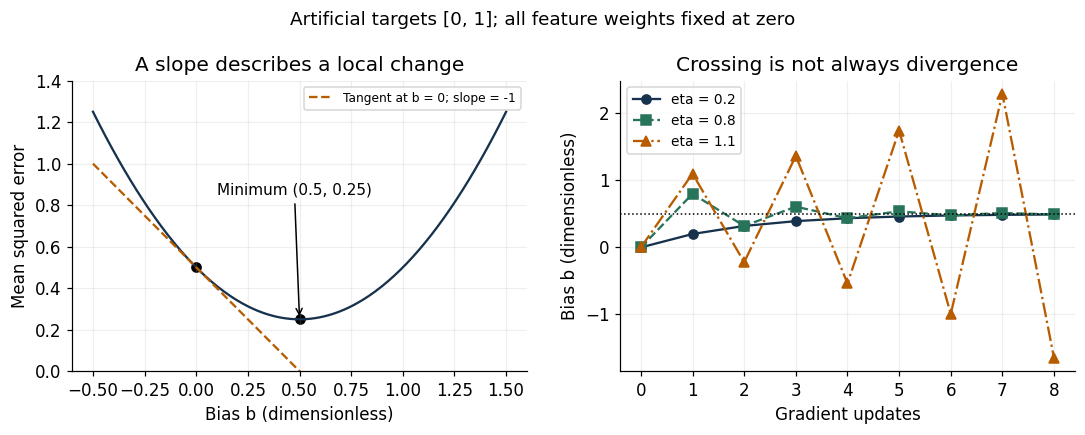

In [13]:
# Artificial bias-only squared loss; weights fixed to zero, targets [0, 1].
rates = [.2, .8, 1.1]
paths = {}
for rate in rates:
    path = [0.]
    for _ in range(8):
        path.append(path[-1] - rate * (2 * path[-1] - 1))
    paths[rate] = np.array(path)
table(pd.DataFrame({"eta": rates, "Old b": [0.] * 3, "Old derivative": [-1.] * 3,
                    "New b": [paths[r][1] for r in rates],
                    "New MSE": [(paths[r][1] - .5) ** 2 + .25 for r in rates]}),
      "Artificial bias-only first update; same targets, initial b = 0 and old MSE = 0.5")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bb_grid = np.linspace(-.5, 1.5, 200)
axes[0].plot(bb_grid, (bb_grid - .5) ** 2 + .25, color=BLUE)
axes[0].plot(bb_grid, .5 - bb_grid, "--", color=ORANGE, label="Tangent at b = 0; slope = -1")
axes[0].scatter([0, .5], [.5, .25], marker="o", color="black")
axes[0].annotate("Minimum (0.5, 0.25)", xy=(.5, .25), xytext=(.1, .85),
                 arrowprops=dict(arrowstyle="->"), fontsize=10)
axes[0].set(xlabel="Bias b (dimensionless)", ylabel="Mean squared error", ylim=(0, 1.4),
            title="A slope describes a local change")
axes[0].legend(fontsize=8)
for rate, style, color in zip(rates, ["o-", "s--", "^-."], [BLUE, GREEN, ORANGE]):
    axes[1].plot(range(9), paths[rate], style, color=color, label=f"eta = {rate}")
axes[1].axhline(.5, color="black", linewidth=1, linestyle=":")
axes[1].set(xlabel="Gradient updates", ylabel="Bias b (dimensionless)", title="Crossing is not always divergence")
axes[1].legend(fontsize=9)
fig.suptitle("Artificial targets [0, 1]; all feature weights fixed at zero", fontsize=12)
fig.tight_layout()
plt.show()

The first-step table gives biases 0.2, 0.8, and 1.1 with MSEs 0.34, 0.34, and 0.61. Rate 0.8 crosses the minimizing value yet reduces loss just as much as 0.2 on this step. Rate 1.1 increases loss above the initial 0.5. The oscillations shrink or grow according to $|1-2\eta|$, not merely according to whether a path crosses the minimum.

The tangent on the left describes the slope at $b=0$; it is not the loss curve itself. Extending a local linear approximation too far is precisely why a large step can fail.

## 9. Can we implement full-batch Adaline directly?

**Full-batch gradient descent** computes residuals on all training rows before one simultaneous parameter update. One epoch therefore means one parameter update in this implementation. We use the same small random initial weights and zero bias for each rate comparison.

The history starts with the initial model's MSE at update 0. After each update, we recalculate all predictions and record the new model's MSE. The last recorded value then belongs to the returned weights and bias. This differs deliberately from the official example's pre-update loss history; it makes the displayed state explicit.

**Before execution:** keep the Iris rows, initial parameters, row order, and 15-update budget fixed. Predict whether raw-feature rates 0.0001 and 0.1 will produce similar loss curves. Use the one-dimensional example to explain why the larger rate need not be preferable.

In [14]:
def adaline_gd(data, targets, eta=.01, epochs=15, w0=None, b0=0.):
    data, targets = checked_xy(data, targets)
    if not np.isfinite(eta) or eta <= 0 or not isinstance(epochs, int) or epochs < 1:
        raise ValueError("Use a positive finite eta and a positive integer epoch count.")
    rng = np.random.RandomState(SEED)
    w = rng.normal(0., .01, data.shape[1]) if w0 is None else np.array(w0, dtype=float, copy=True)
    b = float(b0)
    if w.shape != (data.shape[1],) or not np.isfinite(w).all() or not np.isfinite(b):
        raise ValueError("Initial parameters must be finite and match the feature count.")
    losses = [mse(data, targets, w, b)]
    for _ in range(epochs):
        residual = targets - (data @ w + b)
        delta_w = 2 * eta * (data.T @ residual) / len(targets)
        delta_b = 2 * eta * residual.mean()
        w += delta_w
        b += delta_b
        losses.append(mse(data, targets, w, b))
        if not np.isfinite(losses[-1]):
            raise FloatingPointError("Nonfinite MSE: inspect the data scale and learning rate.")
    return w, b, np.array(losses)

raw_runs = {rate: adaline_gd(X, y, eta=rate, epochs=15) for rate in [.0001, .1]}
summary = []
for rate, (w, b, loss) in raw_runs.items():
    summary.append([rate, loss[0], loss[-1], int(np.sum((X @ w + b >= .5) == y))])
table(pd.DataFrame(summary, columns=["eta", "Initial MSE", "MSE after 15 updates", "Correct / 100"]),
      "Raw Iris training sample; same seed-1 initialization; full-batch MSE includes factor 2",
      {"eta": "{:.4f}", "Initial MSE": "{:.6f}", "MSE after 15 updates": "{:.6e}"})

eta,Initial MSE,MSE after 15 updates,Correct / 100
0.0001,0.434769,3.783713e-01,50
0.1000,0.434769,8.774219e+24,50


Both runs start at MSE **0.434769**. After 15 full-batch updates, rate 0.0001 reaches **0.378371**, while rate 0.1 reaches **8.774219e+24**. The latter is numerical divergence in this experiment, not evidence that Adaline's objective has many local minima. Both final models classify only 50 of these 100 training rows correctly; equal accuracy hides radically different continuous errors.

**Before execution:** predict why a shared logarithmic MSE axis makes both trajectories visible but cannot be read as a linear difference in squared error.

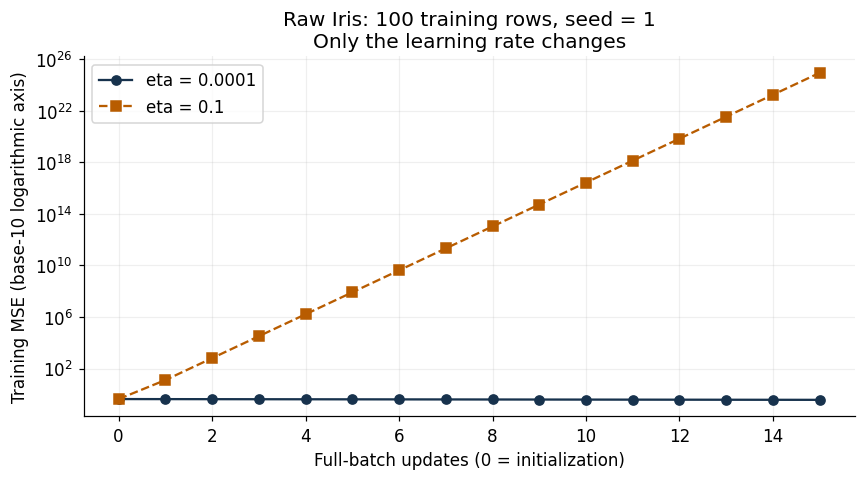

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for rate, style, color in [(.0001, "o-", BLUE), (.1, "s--", ORANGE)]:
    ax.plot(range(16), raw_runs[rate][2], style, color=color, label=f"eta = {rate}")
ax.set_yscale("log", base=10)
ax.set(xlabel="Full-batch updates (0 = initialization)",
       ylabel="Training MSE (base-10 logarithmic axis)",
       title="Raw Iris: 100 training rows, seed = 1\nOnly the learning rate changes")
ax.legend()
fig.tight_layout()
plt.show()

The rate-0.1 curve rises by many orders of magnitude, while the rate-0.0001 curve stays near its initial scale. The common logarithmic axis shows multiplicative changes; consult the exact-value table for differences in MSE. We next investigate why the units and spread of the input coordinates influence usable step sizes.

## 10. What does standardization change, and what does it preserve?

Standardization subtracts a feature's training mean and divides by its training standard deviation. The book gives the transformation; the definitions below specify the exact averaging convention used by NumPy:

$$
\mu_j=\frac1n\sum_i x_{ij},\qquad
\sigma_j=\sqrt{\frac1n\sum_i(x_{ij}-\mu_j)^2},\qquad
x'_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\quad\sigma_j>0.
$$

The mean and standard deviation have the feature's original unit, cm here. The transformed value is dimensionless. NumPy's `std(ddof=0)` uses the divisor $n$ shown above; substituting a divisor of $n-1$ gives a different numerical scale. A zero-variance feature cannot be divided by its standard deviation; the function below rejects that case rather than dividing by zero or silently changing the dataset.

Standardization makes these training columns have mean zero and standard deviation one. It does **not** make the distributions Gaussian, remove outliers, or remove correlation between features. It changes coordinates, not the target labels or which information was measured.

We fit these statistics on all 100 rows only because every experiment here is explicitly a training demonstration. In a model-development workflow, calculate them on training rows only, then reuse those same numbers on validation, test, and future rows. Fitting on a held-out sample would let that sample affect the model's preprocessing before evaluation.

**Before execution:** predict the standardized means and standard deviations. Will the positive correlation between sepal and petal length disappear?

In [16]:
def standardize_training(data):
    data = np.asarray(data, dtype=float)
    if data.ndim != 2 or not all(data.shape) or not np.isfinite(data).all():
        raise ValueError("Training features must be a nonempty finite 2D array.")
    mean = data.mean(axis=0)
    scale = data.std(axis=0, ddof=0)
    if np.any(scale == 0) or not np.isfinite(scale).all():
        raise ValueError("A feature has zero or nonfinite standard deviation; inspect it before scaling.")
    return (data - mean) / scale, mean, scale

Xs, means, scales = standardize_training(X)
cor_raw = np.corrcoef(X.T)[0, 1]
cor_std = np.corrcoef(Xs.T)[0, 1]
table(pd.DataFrame({"Feature": ["Sepal length", "Petal length"],
                    "Training mean (cm)": means, "Training SD (cm)": scales,
                    "Transformed mean": Xs.mean(axis=0),
                    "Transformed SD": Xs.std(axis=0, ddof=0)}),
      "Same 100 Iris training observations; ddof = 0; transformed columns are dimensionless",
      {"Training mean (cm)": "{:.6f}", "Training SD (cm)": "{:.6f}",
       "Transformed mean": "{:.2e}", "Transformed SD": "{:.6f}"})
print(f"Correlation before = {cor_raw:.6f}; after = {cor_std:.6f}")

Feature,Training mean (cm),Training SD (cm),Transformed mean,Transformed SD
Sepal length,5.471000,0.638482,-1.52e-15,1.000000
Petal length,2.861000,1.442283,-1.65e-16,1.000000


Correlation before = 0.812458; after = 0.812458


The training means are **[5.471000, 2.861000] cm** and the standard deviations are **[0.638482, 1.442283] cm**. Transformed means are near zero to floating-point precision and transformed standard deviations round to one. Correlation remains **0.812458** before and after scaling. Thus unit variance is not evidence of independent features or circular loss contours.

### Can raw and standardized weights represent the same predictor?

This course-added derivation substitutes $x'_j=(x_j-\mu_j)/\sigma_j$ into a standardized model. Let primed parameters refer to standardized coordinates:

$$
\begin{aligned}
z&=\sum_j w'_j\frac{x_j-\mu_j}{\sigma_j}+b'\\
 &=\sum_j\left(\frac{w'_j}{\sigma_j}\right)x_j
  +\left(b'-\sum_j\frac{w'_j\mu_j}{\sigma_j}\right).
\end{aligned}
$$

Therefore the equivalent raw parameters are:

$$
w_j=\frac{w'_j}{\sigma_j},\qquad
b=b'-\sum_j\mu_j\frac{w'_j}{\sigma_j}.
$$

With nonzero scales, this transformation preserves every activation and hence every threshold prediction. It does not preserve the path taken by ordinary gradient descent: parameter-coordinate distances and gradient components change.

To compare coordinate systems, hold the initial predictor fixed rather than naively using the same numbers for weights with different meanings. Start both models at all-zero weights and bias; they then both predict activation zero for every row. Hold the sample, full-batch procedure, 20-update budget, and numeric learning rate 0.02 fixed. Only the feature parameterization changes. A common numeric learning rate does not imply the same effective change in the original feature space.

**Before execution:** predict whether the two final MSEs must be identical merely because the two coordinate systems can express the same set of linear predictors.

In [17]:
raw_control = adaline_gd(X, y, eta=.02, epochs=20, w0=np.zeros(m))
std_control = adaline_gd(Xs, y, eta=.02, epochs=20, w0=np.zeros(m))
sw, sb, _ = std_control
equivalent_raw_w = sw / scales
equivalent_raw_b = sb - means @ equivalent_raw_w
mapping_error = np.max(abs((Xs @ sw + sb) - (X @ equivalent_raw_w + equivalent_raw_b)))
table(pd.DataFrame({"Coordinates": ["Raw cm", "Standardized"],
                    "Initial MSE": [raw_control[2][0], std_control[2][0]],
                    "MSE after 20 updates": [raw_control[2][-1], std_control[2][-1]]}),
      "Controlled Iris comparison: zero initial predictor, eta = 0.02, same 20 full-batch updates",
      {"Initial MSE": "{:.6f}", "MSE after 20 updates": "{:.6f}"})
print(f"Largest activation difference after parameter mapping: {mapping_error:.2e}")

Coordinates,Initial MSE,MSE after 20 updates
Raw cm,0.500000,0.038064
Standardized,0.500000,0.099604


Largest activation difference after parameter mapping: 3.33e-16


Starting from MSE 0.5, the raw-coordinate model reaches **0.038064**, while the standardized-coordinate model reaches **0.099604** after the same 20 full-batch updates at rate 0.02. Here the raw-coordinate run has the **lower** MSE: standardization is not guaranteed to reduce error more quickly at every fixed numerical rate and budget. Their optimization paths differ despite their equal initial predictions. Mapping the standardized model back into raw coordinates changes its activations by at most **3.33e-16**, a floating-point-scale discrepancy. The transformation preserves the represented model, not the steps that trained it.

**Check your reasoning:** if you wanted to attribute a difference in convergence to scaling, why would changing the initialization, learning rate, and epoch budget at the same time weaken that comparison?

## 11. Why do the loss contours and usable learning rates change?

This section supplies a **course-added mathematical explanation** of Adaline's convex loss and of the coordinate effect we just observed. The textbook motivates gradient descent and scaling graphically; the following matrix derivation makes the conditions explicit.

Append a column of ones to $X$ so that the bias becomes the last parameter. Define $A=[X,\mathbf1]\in\mathbb R^{n\times(m+1)}$ and $\boldsymbol\beta=(w_1,\ldots,w_m,b)^\top$. Then:

$$
L(\boldsymbol\beta)=\frac1n(\mathbf y-A\boldsymbol\beta)^\top(\mathbf y-A\boldsymbol\beta).
$$

Expanding this scalar quadratic gives:

$$
L=\frac1n\left(\mathbf y^\top\mathbf y
-2\boldsymbol\beta^\top A^\top\mathbf y
+\boldsymbol\beta^\top A^\top A\boldsymbol\beta\right).
$$

Its gradient and matrix of second derivatives, the **Hessian**, are:

$$
\nabla L=\frac2n A^\top(A\boldsymbol\beta-\mathbf y),\qquad
H=\frac2n A^\top A.
$$

For any parameter-direction vector $\mathbf v$,

$$
\mathbf v^\top H\mathbf v=\frac2n\lVert A\mathbf v\rVert_2^2\ge0.
$$

Thus $H$ is positive semidefinite and the quadratic is convex: there is no non-global local minimum to trap this full-batch Adaline optimizer. If the columns of $A$ are linearly independent, the quadratic is strictly convex and the minimizing parameter vector is unique. Otherwise different parameters can attain the same minimum. Setting the gradient to zero gives the normal equations $A^\top A\boldsymbol\beta^*=A^\top\mathbf y$; the numerical check uses `lstsq` rather than explicitly inverting this matrix.

### A constant-step condition, not an unconditional guarantee

Let $t$ count parameter updates, and let $I$ be the $(m+1)\times(m+1)$ identity matrix. Subtract the minimizing parameter vector from the gradient update and use the fact that $\nabla L(\boldsymbol\beta^*)=0$:

$$
\begin{aligned}
\boldsymbol\beta_{t+1}-\boldsymbol\beta^*
&=(\boldsymbol\beta_t-\boldsymbol\beta^*)
-\eta\left(\nabla L(\boldsymbol\beta_t)-\nabla L(\boldsymbol\beta^*)\right)\\
&=(I-\eta H)(\boldsymbol\beta_t-\boldsymbol\beta^*).
\end{aligned}
$$

An eigenvector $\mathbf v\ne0$ satisfies $H\mathbf v=\lambda\mathbf v$: multiplying by $H$ scales this vector without changing its direction. Its eigenvalue $\lambda$ gives the curvature in that direction under this coordinate convention. The update matrix $I-\eta H$ therefore multiplies that direction's error component by $1-\eta\lambda$. To shrink every positive-curvature component, require $|1-\eta\lambda|<1$, giving:

$$
0<\eta<\frac{2}{\lambda_{\max}(H)}.
$$

This is a condition for fixed-step, full-batch descent on this exact quadratic in its stated numerical coordinates. It is not an SGD bound. A zero-curvature direction need not contract, and floating-point extremes can still cause trouble. The bias-only example had $H=2$, reproducing its upper bound of 1.

**Before execution:** predict whether the two coordinate systems have the same least-squares minimum MSE, and whether they must have the same upper bound for a numeric learning rate. The same expressible predictions do not imply equal curvature in parameter coordinates.

In [18]:
geometry = []
least_squares = {}
for name, data in [("Raw cm", X), ("Standardized", Xs)]:
    A = np.column_stack([data, np.ones(n)])
    H = 2 * A.T @ A / n
    eigenvalues = np.linalg.eigvalsh(H)
    beta_star = np.linalg.lstsq(A, y, rcond=None)[0]
    minimum = mse(data, y, beta_star[:m], beta_star[m])
    least_squares[name] = beta_star
    geometry.append([name, np.linalg.matrix_rank(A), eigenvalues[0], eigenvalues[-1],
                     2 / eigenvalues[-1], minimum])
table(pd.DataFrame(geometry, columns=["Coordinates", "Rank of A", "Smallest eigenvalue",
                    "Largest eigenvalue", "Upper eta bound", "Minimum MSE"]),
      "Iris full-batch MSE Hessian includes bias; bounds apply in each stated parameterization",
      {"Minimum MSE": "{:.8f}", "Upper eta bound": "{:.6f}"})

Coordinates,Rank of A,Smallest eigenvalue,Largest eigenvalue,Upper eta bound,Minimum MSE
Raw cm,3,0.0129,80.9901,0.024694,0.01215085
Standardized,3,0.3751,3.6249,0.551737,0.01215085


Both augmented matrices have rank 3, the full column count, and both yield minimum training MSE **0.01215085**. The full-batch upper bounds differ: **0.024694** in raw coordinates and **0.551737** after standardization. Raw rate 0.1 exceeds its bound; standardized rate 0.5 is below its bound. This connects a numerical condition to the earlier divergence rather than attributing it to a vague need for a stronger model.

### What do actual two-weight contours look like?

A contour joins parameter pairs with equal loss. To draw a two-dimensional picture of a three-parameter model, hold the bias fixed. In each coordinate system below, hold it at that system's least-squares value and vary the two weights around their minimizing values. These are **different coordinate slices**, not the paths of the earlier training runs. The contour levels are identical increases in MSE above the minimum. Axes show parameter differences, so the centered marker is zero by construction; the fitted weights themselves are not zero.

**Before execution:** given the correlation of 0.812458 after standardization, predict whether its contours will be circular or still tilted and elongated.

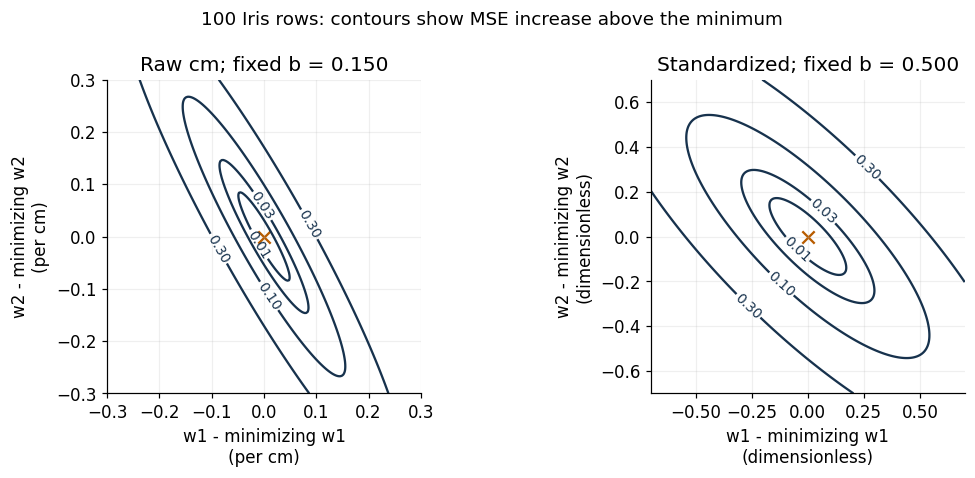

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, name, data, span in zip(axes, ["Raw cm", "Standardized"], [X, Xs], [(.30, .30), (.7, .7)]):
    beta_star = least_squares[name]
    d1 = np.linspace(-span[0], span[0], 220)
    d2 = np.linspace(-span[1], span[1], 220)
    W1, W2 = np.meshgrid(d1, d2)
    # At the least-squares solution, loss increments have this exact quadratic form.
    G = data.T @ data / n
    increase = G[0, 0] * W1 ** 2 + 2 * G[0, 1] * W1 * W2 + G[1, 1] * W2 ** 2
    contours = ax.contour(W1, W2, increase, levels=[.01, .03, .1, .3], colors=BLUE)
    ax.clabel(contours, inline=True, fontsize=9, fmt="%.2f")
    ax.scatter([0], [0], color=ORANGE, marker="x", s=65)
    units = "per cm" if name == "Raw cm" else "dimensionless"
    ax.set(xlabel=f"w1 - minimizing w1\n({units})", ylabel=f"w2 - minimizing w2\n({units})",
           title=f"{name}; fixed b = {beta_star[-1]:.3f}")
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("100 Iris rows: contours show MSE increase above the minimum", fontsize=12)
fig.tight_layout()
plt.show()

The standardized contours remain tilted, not circular. Their labeled levels 0.01, 0.03, 0.10, and 0.30 are **increases** above the minimum MSE, not classification-error rates. The raw panel uses reciprocal-cm weight coordinates; the standardized panel uses dimensionless weights. Different axis spans and fixed biases mean the figures should not be interpreted as identical physical distances traveled by an optimizer.

The noncircular standardized contours agree with the nonzero correlation measured earlier. Standardization can make useful numeric step sizes larger in this example without eliminating every difference in curvature.

## 12. Does zero classification error mean zero Adaline loss?

Now use standardized Iris features, the source's seed-1 initialization, rate 0.5, and 20 full-batch updates. This is a **new optimization setup**, not the one-factor rate-0.02 scaling comparison. We selected a rate below the calculated standardized bound to illustrate learning; all outcomes remain training observations.

**Before execution:** predict whether correctly classifying all 100 rows would force every activation to be exactly 0 or 1. Also predict whether the activation range must lie inside the interval $[0,1]$.

Correct / 100,Final MSE,Least-squares MSE,Min activation,Max activation
100,0.01220809,0.01215085,-0.175127,1.278603


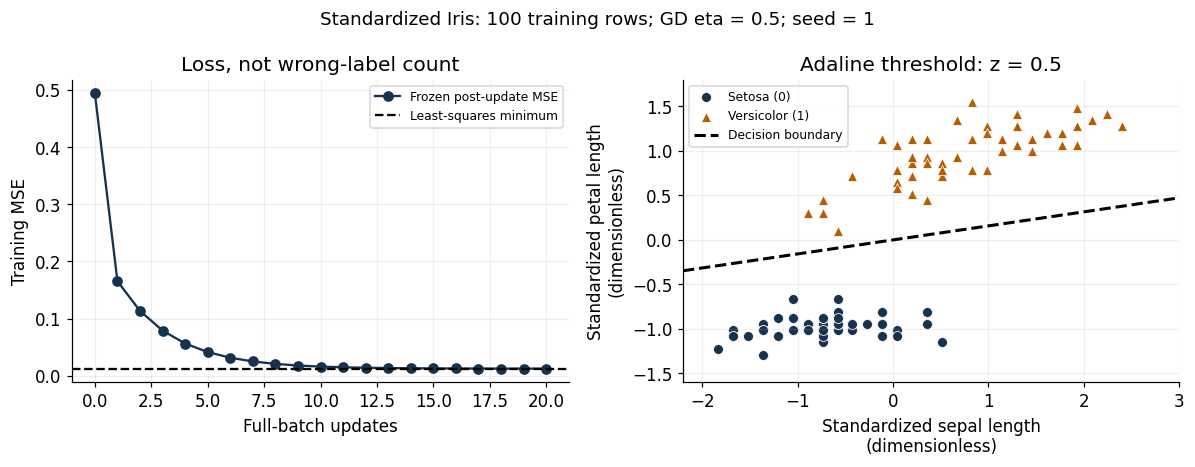

In [20]:
gw, gb, gl = adaline_gd(Xs, y, eta=.5, epochs=20)
gz = Xs @ gw + gb
correct = int(np.sum((gz >= .5) == y))
table(pd.DataFrame({"Correct / 100": [correct], "Final MSE": [gl[-1]],
                    "Least-squares MSE": [geometry[1][-1]], "Min activation": [gz.min()],
                    "Max activation": [gz.max()]}),
      "Standardized Iris training sample; full-batch Adaline, eta = 0.5, 20 updates, seed = 1",
      {"Final MSE": "{:.8f}", "Least-squares MSE": "{:.8f}",
       "Min activation": "{:.6f}", "Max activation": "{:.6f}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(range(21), gl, "o-", color=BLUE, label="Frozen post-update MSE")
axes[0].axhline(geometry[1][-1], color="black", linestyle="--", label="Least-squares minimum")
axes[0].set(xlabel="Full-batch updates", ylabel="Training MSE", title="Loss, not wrong-label count")
axes[0].legend(fontsize=8)
flowers(axes[1], Xs, y, standardized=True)
boundary(axes[1], gw, gb, .5, [-2.2, 3])
axes[1].set(xlim=(-2.2, 3), ylim=(-1.6, 1.8), title="Adaline threshold: z = 0.5")
axes[1].legend(fontsize=8)
fig.suptitle("Standardized Iris: 100 training rows; GD eta = 0.5; seed = 1", fontsize=12)
fig.tight_layout()
plt.show()

The fitted model gets **100/100** training labels correct, but its MSE is **0.01220809**, still above the least-squares value **0.01215085**. Twenty updates brought it close to that minimum; they did not establish exact minimization. Its activations range from **-0.175127 to 1.278603**, extending outside $[0,1]$. These are not probabilities.

The dashed boundary corresponds to $w_1x'_1+w_2x'_2+b=0.5$, not the Perceptron's threshold of zero. Both rules use straight boundaries, but their objectives and numeric thresholds differ. Changing only an activation to a sigmoid would not, by itself, give the logistic-regression training objective; Chapter 3 introduces the corresponding model and loss together.

## 13. What changes when we update after each example?

Full-batch Adaline calculates a gradient from all $n$ residuals before changing parameters. **Stochastic gradient descent (SGD)** can change parameters after a single example. This reduces the amount of data needed for one update, but does not mean that a single update contains the same information or takes the same path.

For the single-example squared loss $\ell_i=(y_i-z_i)^2$, the same chain rule gives:

$$
\frac{\partial\ell_i}{\partial w_j}=-2(y_i-z_i)x_{ij},\qquad
\frac{\partial\ell_i}{\partial b}=-2(y_i-z_i).
$$

Consequently the update is:

$$
\mathbf w\leftarrow\mathbf w+2\eta(y_i-z_i)\mathbf x^{(i)\top},\qquad
b\leftarrow b+2\eta(y_i-z_i).
$$

There is no divisor $n$ in this single-example loss. We keep the factor 2 consistently with the chapter's MSE and the official SGD code. If instead you define half-squared loss, its gradient has no factor 2; using the same numeric $\eta$ then halves the step. The definitions of both loss and learning rate must be read together.

For a uniformly sampled example at fixed parameters, the average of the single-example gradients equals the full average gradient. Individual gradients may point in different directions; a step for one row need not reduce the full dataset's loss. The objective itself is fixed. It is the gradient estimate and parameter trajectory that vary with sampling. In the implementation below, we permute all rows once per epoch, as in the textbook, rather than sample independently with replacement.

### What exactly will the loss history record?

We preserve two quantities. `Within-epoch mean loss` averages each row's squared residual **just before that row's update**. Those residuals come from a succession of changing models. `End MSE` evaluates all rows with one frozen model after the epoch. Only the latter is the same evaluation procedure as our full-batch end-of-epoch MSE.

Shuffling must use one shared permutation for features and targets. With 100 rows, a permutation contains the indices 0 through 99 exactly once. Separately permuting features and targets would assign flowers incorrect species labels.

**Before execution:** predict whether the last within-epoch average must equal the final frozen MSE. Count how many parameter updates 15 epochs require for 100 rows, and compare that count with full-batch descent.

In [21]:
def adaline_sgd(data, targets, eta=.01, epochs=15, decreasing=False):
    data, targets = checked_xy(data, targets)
    if not np.isfinite(eta) or eta <= 0 or not isinstance(epochs, int) or epochs < 1:
        raise ValueError("Use a positive finite eta and a positive integer epoch count.")
    rng = np.random.RandomState(SEED)
    w = rng.normal(0., .01, data.shape[1])
    b = 0.
    history = [[0, np.nan, mse(data, targets, w, b)]]
    updates = 0
    for epoch in range(1, epochs + 1):
        row_losses = []
        order = rng.permutation(len(targets))
        for i in order:
            rate = .1 / (updates + 10) if decreasing else eta
            residual = targets[i] - (data[i] @ w + b)
            row_losses.append(residual ** 2)
            w += 2 * rate * residual * data[i]
            b += 2 * rate * residual
            updates += 1
        end_loss = mse(data, targets, w, b)
        if not np.isfinite(end_loss):
            raise FloatingPointError("Nonfinite MSE: inspect features and step sizes.")
        history.append([epoch, np.mean(row_losses), end_loss])
    return w, b, pd.DataFrame(history, columns=["Epoch", "Within-epoch mean loss", "End MSE"])

sgw, sgb, sh = adaline_sgd(Xs, y)
gw15, gb15, gl15 = adaline_gd(Xs, y, eta=.5, epochs=15)
table(sh.loc[[1, 5, 10, 15]],
      "Standardized Iris SGD: seed = 1, shuffled rows, constant eta = 0.01; 100 updates per epoch",
      {"Within-epoch mean loss": "{:.8f}", "End MSE": "{:.8f}"})
table(pd.DataFrame({"Optimizer": ["Full-batch GD", "SGD"], "eta": [.5, .01], "Epochs": [15, 15],
                    "Parameter updates": [15, 1500], "Final frozen MSE": [gl15[-1], sh.iloc[-1]["End MSE"]]}),
      "Same standardized Iris rows and initial parameters; different step sizes and update budgets",
      {"Final frozen MSE": "{:.8f}"})

Epoch,Within-epoch mean loss,End MSE
1,0.13444266,0.03613889
5,0.01405268,0.01316518
10,0.01277956,0.01222131
15,0.01254362,0.01223622


Optimizer,eta,Epochs,Parameter updates,Final frozen MSE
Full-batch GD,0.5000,15,15,0.01260761
SGD,0.0100,15,1500,0.01223622


At epoch 15, SGD's within-epoch mean is **0.01254362**, while its frozen-model MSE is **0.01223622**. These are different calculations, not conflicting measurements of one frozen model. The full-batch run's frozen MSE is **0.01260761** after 15 updates; SGD used 1,500 updates. Both visited 1,500 training examples for learning, but the vectorized full-batch and row-by-row calculations have different computational costs.

The comparison uses rates 0.5 and 0.01, so it is a demonstration of two specified training procedures, not an isolated test of optimizer identity. We have not measured wall-clock time. Extra full-sample evaluations for the learning curves are also overhead, not optimizer updates.

**Before execution:** predict why an SGD end-MSE curve can fluctuate even on Adaline's convex objective, and why this does not establish the presence of bad local minima.

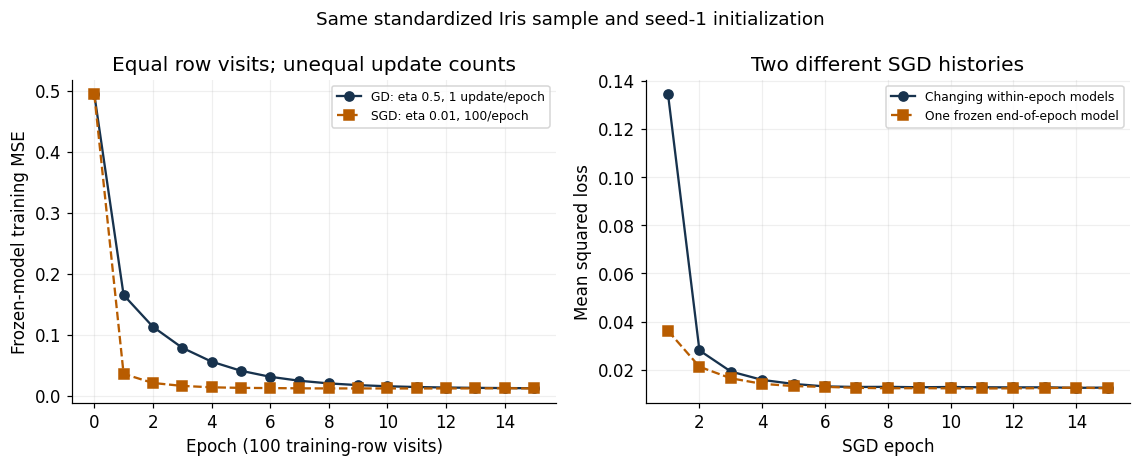

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].plot(range(16), gl15, "o-", color=BLUE, label="GD: eta 0.5, 1 update/epoch")
axes[0].plot(sh["Epoch"], sh["End MSE"], "s--", color=ORANGE, label="SGD: eta 0.01, 100/epoch")
axes[0].set(xlabel="Epoch (100 training-row visits)", ylabel="Frozen-model training MSE",
            title="Equal row visits; unequal update counts")
axes[0].legend(fontsize=8)
axes[1].plot(sh["Epoch"][1:], sh["Within-epoch mean loss"][1:], "o-", color=BLUE, label="Changing within-epoch models")
axes[1].plot(sh["Epoch"][1:], sh["End MSE"][1:], "s--", color=ORANGE, label="One frozen end-of-epoch model")
axes[1].set(xlabel="SGD epoch", ylabel="Mean squared loss", title="Two different SGD histories")
axes[1].legend(fontsize=8)
fig.suptitle("Same standardized Iris sample and seed-1 initialization", fontsize=12)
fig.tight_layout()
plt.show()

The left panel compares the same metric at the end of a pass, not equal numbers of parameter updates. The right panel separates an average over changing models from evaluation of one model. Its two final values, **0.01254362** and **0.01223622**, are close here but need not agree. The finite run cannot establish universal optimizer superiority or exact convergence.

## 14. What do mini-batches, decreasing rates, and continued learning add?

### Mini-batches average several examples before updating

The textbook describes **mini-batch gradient descent** as using a subset of rows per update. The following course-added equation makes its connection to the previous two methods explicit. For a nonempty batch $B$, compute all $e_i$ at the same old parameter state:

$$
L_B=\frac1{|B|}\sum_{i\in B}e_i^2,\qquad
\Delta\mathbf w=\frac{2\eta}{|B|}\sum_{i\in B}e_i\mathbf x^{(i)\top},\qquad
\Delta b=\frac{2\eta}{|B|}\sum_{i\in B}e_i.
$$

Batch size 1 gives the single-example update; batch size $n$ gives the full-batch update. Averaging batch gradients evaluated at the same old parameters can recover a full gradient. Performing sequential updates after each batch generally does not: later residuals then use changed weights.

**Before execution:** on the earlier artificial three-row example, predict whether the average of three single-row gradients at the same initial parameters equals the full gradient. Would the parameters also match after three sequential single-row updates at the same rate?

In [23]:
def batch_update(data, targets, w, b, eta):
    # Explicit 2D X / 1D y interface, even for one example; no hidden state.
    data, targets = checked_xy(data, targets)
    w = np.asarray(w, dtype=float)
    if w.shape != (data.shape[1],) or not np.isfinite(w).all() or not np.isfinite(b):
        raise ValueError("Finite parameters must match the feature count.")
    if not np.isfinite(eta) or eta <= 0:
        raise ValueError("eta must be finite and positive.")
    residual = targets - (data @ w + b)
    return w + 2 * eta * data.T @ residual / len(targets), float(b + 2 * eta * residual.mean())

single_gradients = np.array([np.r_[-2 * e * xi, -2 * e] for xi, e in zip(toy_X, toy_e)])
full_w, full_b = batch_update(toy_X, toy_y, toy_beta[:2], toy_beta[2], .1)
seq_w, seq_b = toy_beta[:2].copy(), float(toy_beta[2])
for i in range(3):
    seq_w, seq_b = batch_update(toy_X[i:i+1], toy_y[i:i+1], seq_w, seq_b, .1)
table(pd.DataFrame({"Parameter": ["w1", "w2", "b"],
                    "Initial": toy_beta, "One full-batch update": np.r_[full_w, full_b],
                    "Three sequential row updates": np.r_[seq_w, seq_b]}),
      "Artificial three-row example; eta = 0.1 throughout; different parameter-update counts",
      {"Initial": "{:.6f}", "One full-batch update": "{:.6f}", "Three sequential row updates": "{:.6f}"})
print("Mean single-row gradients equals full gradient at the old state:",
      np.allclose(single_gradients.mean(axis=0), gradient))
print("Final parameters equal after the two procedures:",
      np.allclose(np.r_[full_w, full_b], np.r_[seq_w, seq_b]))

Parameter,Initial,One full-batch update,Three sequential row updates
w1,0.200000,0.273333,0.375200
w2,-0.100000,-0.020000,0.134400
b,0.300000,0.360000,0.373600


Mean single-row gradients equals full gradient at the old state: True
Final parameters equal after the two procedures: False


The fixed-state gradient comparison returns `True`, but equality of final parameters returns `False`. One full-batch update produces $(w_1,w_2,b)=(0.273333,-0.02,0.36)$. Three sequential row updates produce $(0.3752,0.1344,0.3736)$. The latter procedure uses three updates and recalculates residuals along the way, so it is not merely another spelling of the first calculation.

### Decrease the learning rate as updates accumulate

The book gives a decreasing-rate example of the form:

$$
\eta_t=\frac{c_1}{t+c_2},\qquad c_1>0,\ c_2>0,\ t=0,1,2,\ldots.
$$

Here $t$ counts **parameter updates**, not epochs. Positive constants make the rate positive and decreasing; the schedule alone does not guarantee a particular convergence rate or good finite-budget result. Smaller later updates can reduce persistent movement, but shrinking too early can leave substantial error within the available budget.

**Before execution:** with $c_1=0.1$ and $c_2=10$, calculate the initial rate and the rate at update 100. Both runs below have the same first step, initial parameters, sample orders, and 1,500-update budget; one keeps rate 0.01 and one decreases it. Predict whether the decreasing schedule is logically guaranteed to yield lower final training MSE.

In [24]:
dw, db, dh = adaline_sgd(Xs, y, epochs=15, decreasing=True)
update_index = np.array([0, 1, 10, 100, 1499])
table(pd.DataFrame({"Update index t": update_index,
                    "Constant eta": np.full(len(update_index), .01),
                    "0.1 / (t + 10)": .1 / (update_index + 10)}),
      "Course implementation of the textbook's schedule; t starts at zero", {"0.1 / (t + 10)": "{:.8f}"})
table(pd.DataFrame({"Schedule": ["Constant 0.01", "0.1 / (t + 10)"],
                    "Parameter updates": [1500, 1500],
                    "Final frozen MSE": [sh.iloc[-1]["End MSE"], dh.iloc[-1]["End MSE"]]}),
      "Same standardized Iris observations, initialization and shuffled orders; only schedule changes",
      {"Final frozen MSE": "{:.8f}"})

Update index t,Constant eta,0.1 / (t + 10)
0,0.0100,0.01000000
1,0.0100,0.00909091
10,0.0100,0.00500000
100,0.0100,0.00090909
1499,0.0100,0.00006627


Schedule,Parameter updates,Final frozen MSE
Constant 0.01,1500,0.01223622
0.1 / (t + 10),1500,0.07650739


The rate starts at 0.01 and is about 0.00090909 at update 100. After 1,500 updates the decreasing-rate model has MSE **0.07650739**, compared with **0.01223622** for the constant-rate run. This is evidence about these two chosen schedules and this budget. It is not a theorem that decreasing or constant rates always win.

### Continue from existing parameters without hiding the state

**Online learning** updates a model as additional labeled observations become available. The official `partial_fit` demonstration illustrates continuation rather than restarting. Our `batch_update` function makes the previous weights and bias explicit arguments. It returns new parameters and does not refit the scaling statistics.

The next calculation **reuses an already inspected Iris training row** to demonstrate the mechanics; it is not a new data stream or new evaluation evidence. Select the training row with the largest residual magnitude under the fitted SGD model, keep its stored standardized coordinates, and perform one update. There is no need for a true target when predicting; it becomes necessary when performing this supervised update.

**Before execution:** predict whether reducing this row's squared loss guarantees a reduction in full-sample MSE. Use the difference between an individual gradient and the full gradient in your explanation.

In [25]:
row = int(np.argmax((y - (Xs @ sgw + sgb)) ** 2))
continued_w, continued_b = batch_update(Xs[row:row+1], y[row:row+1], sgw, sgb, .01)
before_row = mse(Xs[row:row+1], y[row:row+1], sgw, sgb)
after_row = mse(Xs[row:row+1], y[row:row+1], continued_w, continued_b)
before_all = mse(Xs, y, sgw, sgb)
after_all = mse(Xs, y, continued_w, continued_b)
table(pd.DataFrame({"Evaluation scope": [f"Reused Iris row {row}", "All 100 training rows"],
                    "Before update MSE": [before_row, before_all],
                    "After update MSE": [after_row, after_all]}),
      f"One continued update on the previously inspected row {row}; eta = 0.01; original training scale retained",
      {"Before update MSE": "{:.8f}", "After update MSE": "{:.8f}"})

Evaluation scope,Before update MSE,After update MSE
Reused Iris row 98,0.15301553,0.14488254
All 100 training rows,0.01223622,0.01236049


For reused row **98**, the squared loss changes from **0.15301553** to **0.14488254**. Over all 100 rows, MSE changes from **0.01223622** to **0.01236049**. Inspect both scopes before describing the update as an improvement: its chosen row and the full training sample need not benefit together.

The call uses a `(1, 2)` feature array and a one-element target array. A new model can also begin from explicit zero weights and zero bias with this interface. Accidentally passing a bare feature vector is rejected instead of guessing whether its entries are examples or features. In a real stream, records of arrival order, available labels, feature definitions, and previously fitted preprocessing would also be needed. This one repeated-row demonstration does not validate a deployed streaming system.

## 15. What can we conclude, and what still needs evaluation?

Perceptron and Adaline both learn linear scores, but they answer different training questions. A zero-update Perceptron pass means that its classifications no longer require corrections on the visited sample. A low Adaline MSE means its real-valued activations approach the numerical targets on the rows used in that calculation. Neither statement estimates accuracy on new flowers.

The chapter's figures show geometry and optimization under declared conditions. In particular:

- All 100 selected Iris rows were available for fitting and inspection. Scaling statistics also used these rows. No held-out test metric has been reported.
- Selecting setosa versus versicolor gives a visibly separable problem. Measurement error, another species, different sampling, or a different target may change what a linear model can represent.
- A decreasing loss can stop above the mathematical minimum. A zero class-error count can coexist with positive MSE and activations outside $[0,1]$.
- Standardization preserves the set of representable linear predictors when every scale is nonzero. It can change optimization paths, but does not remove feature correlation or provide new biological evidence.
- Learning curves need the metric, model state, and update budget. Averages over successive models are not interchangeable with loss evaluated using one frozen model.

### Two questions for discussion

#### Question 1 - What exactly has converged?

A group claims: “The Perceptron converged at epoch 5, and standardized Adaline converged because it classified every training flower correctly.” Using the actual update-count table, frozen-model errors, final Adaline MSE, and least-squares reference, which parts of this statement are justified and which need a narrower description? State a separate observable stopping condition for each algorithm, and explain what evidence would still be missing before claiming accurate predictions for newly collected flowers.

#### Question 2 - Which comparison would support your recommendation?

A group recommends replacing raw-feature full-batch descent with standardized SGD because its training curve appears to fall faster. Use the raw-rate experiment, controlled scaling comparison, and GD/SGD update counts to decide whether the displayed evidence identifies the effect of scaling, the effect of the optimizer, both, or neither. Design two comparisons that separate these effects: specify the data, initial predictor, learning-rate policy, computational budget, frozen-model metric, and an observed result that would make you withdraw the recommendation. Explain how you would keep later evaluation rows out of preprocessing and tuning.

### Continue studying

If a step remains unclear, return first to the scalar Perceptron update or the three-row MSE derivative table, and trace each parameter change by hand. Then compare that calculation with the NumPy operation that performs the same sum. For additional mathematical depth, revisit the Hessian derivation and explain why its rate condition applies to full-batch descent rather than automatically applying to SGD.

Keep your own annotated calculation, a rerun of a comparison with its fixed conditions recorded, and a short explanation of what its outputs do and do not establish. These support your understanding and later project work; this chapter adds no new submission schedule or grading requirement.

Chapter 3 uses established library interfaces to study additional classifiers, including logistic regression. The interface can reduce implementation work, but it does not remove the need to understand the objective, data transformation, parameter updates, and evaluation evidence.

### Sources and reproduction notes

- Raschka, Liu, and Mirjalili, *Machine Learning with PyTorch and Scikit-Learn*, Chapter 2: net input and Perceptron (pp.19-35), Adaline and MSE gradients (pp.35-43), scaling (pp.43-45), and stochastic/online learning (pp.45-51).
- [Official Chapter 2 code](https://github.com/rasbt/machine-learning-book/tree/main/ch02) provides the reference implementations and experiments. The course uses original explanatory code, current floating-point types, explicit input shapes, frozen post-update MSE, and newly generated plots. It does not reproduce the textbook's artwork or guarantee identical numbers to its older data file.
- [Scikit-learn Iris documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) describes the bundled loader used here. The selected data are unmodified Iris observations; all non-Iris numerical examples are explicitly labeled artificial. No file downloads or filesystem-specific paths are required by the notebook.

Run all cells in order after restarting the kernel. The setup table records the executed versions. Functions check the intended input shape and reject nonfinite features; they are deliberately small teaching implementations, not production estimators. If a learning curve becomes nonfinite, inspect the feature scale, input values, and step size before interpreting it. If a plot looks different after a code change, regenerate its output and revise the interpretation rather than keeping old numbers.